### Entraînement complet d'un **nouveau** SR-VAE (100 epochs + early stopping)

Ce notebook entraîne un modèle `ConvConditionalVAE` **depuis zéro** (pas de chargement de poids existants), avec split train/val/test, early stopping, puis évaluation et visualisation sur le test set.

In [3]:
from pathlib import Path
import json
import random
import copy
import numpy as np
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import matplotlib.pyplot as plt

from SR_VAE import SRPairsDataset, ConvConditionalVAE, sr_vae_loss

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


In [6]:
# --------------------
# Configuration
# --------------------
HIGH_SIZE = 64
LOW_SIZE = 32
BATCH_SIZE = 32
NUM_EPOCHS = 100
LR = 2e-4
BETA_KL = 0.1
PATIENCE = 12
MIN_DELTA = 1e-4

LATENT_DIM = 64
COND_EMB_DIM = 128
BASE_CHANNELS = 64

ROOT = Path.cwd()
manifest_candidates = [
    ROOT / "Healthy_SR_pairs" / "scale_2" / "manifest.jsonl",
    ROOT / "ImageGeneration" / "Healthy_SR_pairs" / "scale_2" / "manifest.jsonl",
]
MANIFEST_PATH = next((p for p in manifest_candidates if p.exists()), None)
if MANIFEST_PATH is None:
    raise FileNotFoundError(
        "Manifest introuvable. Vérifie Healthy_SR_pairs/scale_2/manifest.jsonl"
    )

OUTPUT_DIR = ROOT / "ImageGeneration" / "sr_vae_outputs_notebook"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BEST_CKPT_PATH = OUTPUT_DIR / "sr_vae_best_notebook.pth"

print("Manifest:", MANIFEST_PATH)
print("Output dir:", OUTPUT_DIR)

Manifest: /Users/julielevita/Desktop/kaggle_projects/Dataset_cancer/ImageGeneration/Healthy_SR_pairs/scale_2/manifest.jsonl
Output dir: /Users/julielevita/Desktop/kaggle_projects/Dataset_cancer/ImageGeneration/ImageGeneration/sr_vae_outputs_notebook


In [7]:
# --------------------
# Dataset + split train/val/test
# --------------------
full_dataset = SRPairsDataset(
    manifest_path=str(MANIFEST_PATH),
    high_size=HIGH_SIZE,
    low_size=LOW_SIZE,
    normalize_pixels=True,
)

n_total = len(full_dataset)
if n_total < 20:
    raise RuntimeError(f"Dataset trop petit: {n_total} échantillons")

idx = np.arange(n_total)
rng = np.random.default_rng(SEED)
rng.shuffle(idx)

n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_idx = idx[:n_train].tolist()
val_idx = idx[n_train:n_train + n_val].tolist()
test_idx = idx[n_train + n_val:].tolist()

train_ds = Subset(full_dataset, train_idx)
val_ds = Subset(full_dataset, val_idx)
test_ds = Subset(full_dataset, test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Total={n_total} | Train={len(train_ds)} | Val={len(val_ds)} | Test={len(test_ds)}")


SRPairsDataset: 2000 paires
Total=2000 | Train=1400 | Val=300 | Test=300


In [9]:
# --------------------
# Nouveau modèle SR-VAE (from scratch)
# --------------------
model = ConvConditionalVAE(
    img_channels=1,
    high_size=HIGH_SIZE,
    latent_dim=LATENT_DIM,
    cond_emb_dim=COND_EMB_DIM,
    base_channels=BASE_CHANNELS,
).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=LR)

history = {"train_total": [], "val_total": [], "train_recon": [], "val_recon": [], "train_kl": [], "val_kl": []}
best_val = float("inf")
best_epoch = -1
best_state = None
patience_count = 0

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    tr_total = tr_recon = tr_kl = 0.0
    n_tr = 0

    pbar = tqdm(train_loader, desc=f"Train {epoch}/{NUM_EPOCHS}", leave=False)
    for low, high in pbar:
        low = low.to(DEVICE)
        high = high.to(DEVICE)

        optimizer.zero_grad()
        recon, mu, logvar = model(low, high)
        total, recon_loss, kl = sr_vae_loss(recon, high, mu, logvar, beta_kl=BETA_KL)
        total.backward()
        optimizer.step()

        tr_total += float(total.item())
        tr_recon += float(recon_loss.item())
        tr_kl += float(kl.item())
        n_tr += 1

        pbar.set_postfix(loss=f"{total.item():.4f}")

    model.eval()
    va_total = va_recon = va_kl = 0.0
    n_va = 0
    with torch.no_grad():
        for low, high in val_loader:
            low = low.to(DEVICE)
            high = high.to(DEVICE)
            recon, mu, logvar = model(low, high)
            total, recon_loss, kl = sr_vae_loss(recon, high, mu, logvar, beta_kl=BETA_KL)

            va_total += float(total.item())
            va_recon += float(recon_loss.item())
            va_kl += float(kl.item())
            n_va += 1

    tr_total /= max(1, n_tr)
    tr_recon /= max(1, n_tr)
    tr_kl /= max(1, n_tr)
    va_total /= max(1, n_va)
    va_recon /= max(1, n_va)
    va_kl /= max(1, n_va)

    history["train_total"].append(tr_total)
    history["val_total"].append(va_total)
    history["train_recon"].append(tr_recon)
    history["val_recon"].append(va_recon)
    history["train_kl"].append(tr_kl)
    history["val_kl"].append(va_kl)

    print(
        f"Epoch {epoch:03d} | "
        f"train={tr_total:.4f} (recon={tr_recon:.4f}, kl={tr_kl:.4f}) | "
        f"val={va_total:.4f} (recon={va_recon:.4f}, kl={va_kl:.4f})"
    )

    if va_total < (best_val - MIN_DELTA):
        best_val = va_total
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, BEST_CKPT_PATH)
        patience_count = 0
        print(f"  -> New best val: {best_val:.4f} (saved)")
    else:
        patience_count += 1
        print(f"  -> No improvement ({patience_count}/{PATIENCE})")

    if patience_count >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

if best_state is None:
    raise RuntimeError("Aucun meilleur état trouvé pendant l'entraînement.")

model.load_state_dict(best_state)
print(f"\nBest epoch: {best_epoch}, best val loss: {best_val:.4f}")
print(f"Best checkpoint: {BEST_CKPT_PATH}")

Epoch 001 | train=0.1647 (recon=0.0389, kl=1.2583) | val=0.0258 (recon=0.0229, kl=0.0292)
  -> New best val: 0.0258 (saved)


Epoch 002 | train=0.0228 (recon=0.0215, kl=0.0135) | val=0.0192 (recon=0.0185, kl=0.0068)
  -> New best val: 0.0192 (saved)


Epoch 003 | train=0.0187 (recon=0.0182, kl=0.0055) | val=0.0171 (recon=0.0167, kl=0.0046)
  -> New best val: 0.0171 (saved)


Epoch 004 | train=0.0173 (recon=0.0169, kl=0.0041) | val=0.0161 (recon=0.0157, kl=0.0036)
  -> New best val: 0.0161 (saved)


Epoch 005 | train=0.0162 (recon=0.0159, kl=0.0034) | val=0.0150 (recon=0.0147, kl=0.0030)
  -> New best val: 0.0150 (saved)


...

Epoch 069 | train=0.0011 (recon=0.0009, kl=0.0018) | val=0.0037 (recon=0.0034, kl=0.0030)
  -> No improvement (8/12)


Epoch 070 | train=0.0011 (recon=0.0009, kl=0.0019) | val=0.0035 (recon=0.0033, kl=0.0026)
  -> No improvement (9/12)


Epoch 071 | train=0.0012 (recon=0.0010, kl=0.0021) | val=0.0035 (recon=0.0034, kl=0.0016)
  -> No improvement (10/12)


Epoch 072 | train=0.0012 (recon=0.0011, kl=0.0019) | val=0.0035 (recon=0.0034, kl=0.0012)
  -> No improvement (11/12)


Epoch 073 | train=0.0012 (recon=0.0010, kl=0.0022) | val=0.0036 (recon=0.0033, kl=0.0028)
  -> No improvement (12/12)
Early stopping triggered at epoch 73.

Best epoch: 61, best val loss: 0.0035
Best checkpoint: /Users/julielevita/Desktop/kaggle_projects/Dataset_cancer/ImageGeneration/ImageGeneration/sr_vae_outputs_notebook/sr_vae_best_notebook.pth


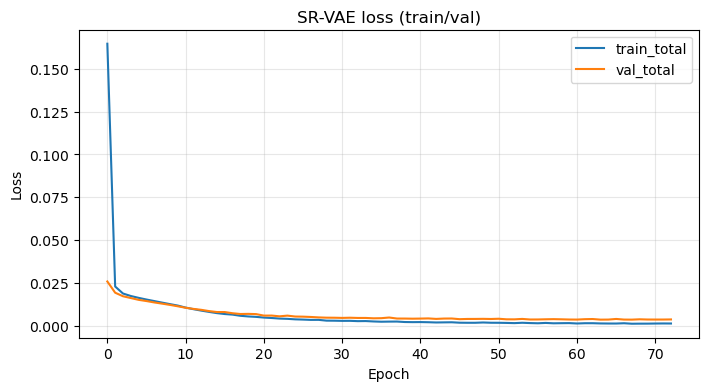

In [10]:
# Courbes train/val
plt.figure(figsize=(8, 4))
plt.plot(history['train_total'], label='train_total')
plt.plot(history['val_total'], label='val_total')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SR-VAE loss (train/val)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
@torch.no_grad()
def psnr_torch(pred: torch.Tensor, target: torch.Tensor, max_val: float = 1.0) -> float:
    mse = F.mse_loss(pred, target).item()
    if mse == 0:
        return float('inf')
    return 20.0 * np.log10(max_val) - 10.0 * np.log10(mse)


# Évaluation moyenne sur test set
model.eval()
psnr_low_list = []
psnr_pseudo_list = []

for low, high in tqdm(test_loader, desc='Test eval', leave=False):
    low = low.to(DEVICE)
    high = high.to(DEVICE)

    pseudo = model.sample_from_low(low)
    low_up = F.interpolate(low, size=(HIGH_SIZE, HIGH_SIZE), mode='nearest')

    for i in range(low.size(0)):
        p_low = psnr_torch(low_up[i].cpu(), high[i].cpu())
        p_ps = psnr_torch(pseudo[i].cpu(), high[i].cpu())
        if np.isfinite(p_low):
            psnr_low_list.append(p_low)
        if np.isfinite(p_ps):
            psnr_pseudo_list.append(p_ps)

mean_low = float(np.mean(psnr_low_list)) if psnr_low_list else float('nan')
mean_pseudo = float(np.mean(psnr_pseudo_list)) if psnr_pseudo_list else float('nan')

print('--- Test metrics (newly trained SR-VAE) ---')
print(f'n_test_images_used: {len(psnr_pseudo_list)}')
print(f'mean PSNR low_up vs high: {mean_low:.2f} dB')
print(f'mean PSNR pseudo_high vs high: {mean_pseudo:.2f} dB')
print(f'mean Δ PSNR (pseudo - low): {mean_pseudo - mean_low:+.2f} dB')

--- Test metrics (newly trained SR-VAE) ---
n_test_images_used: 300
mean PSNR low_up vs high: 21.03 dB
mean PSNR pseudo_high vs high: 27.96 dB
mean Δ PSNR (pseudo - low): +6.93 dB


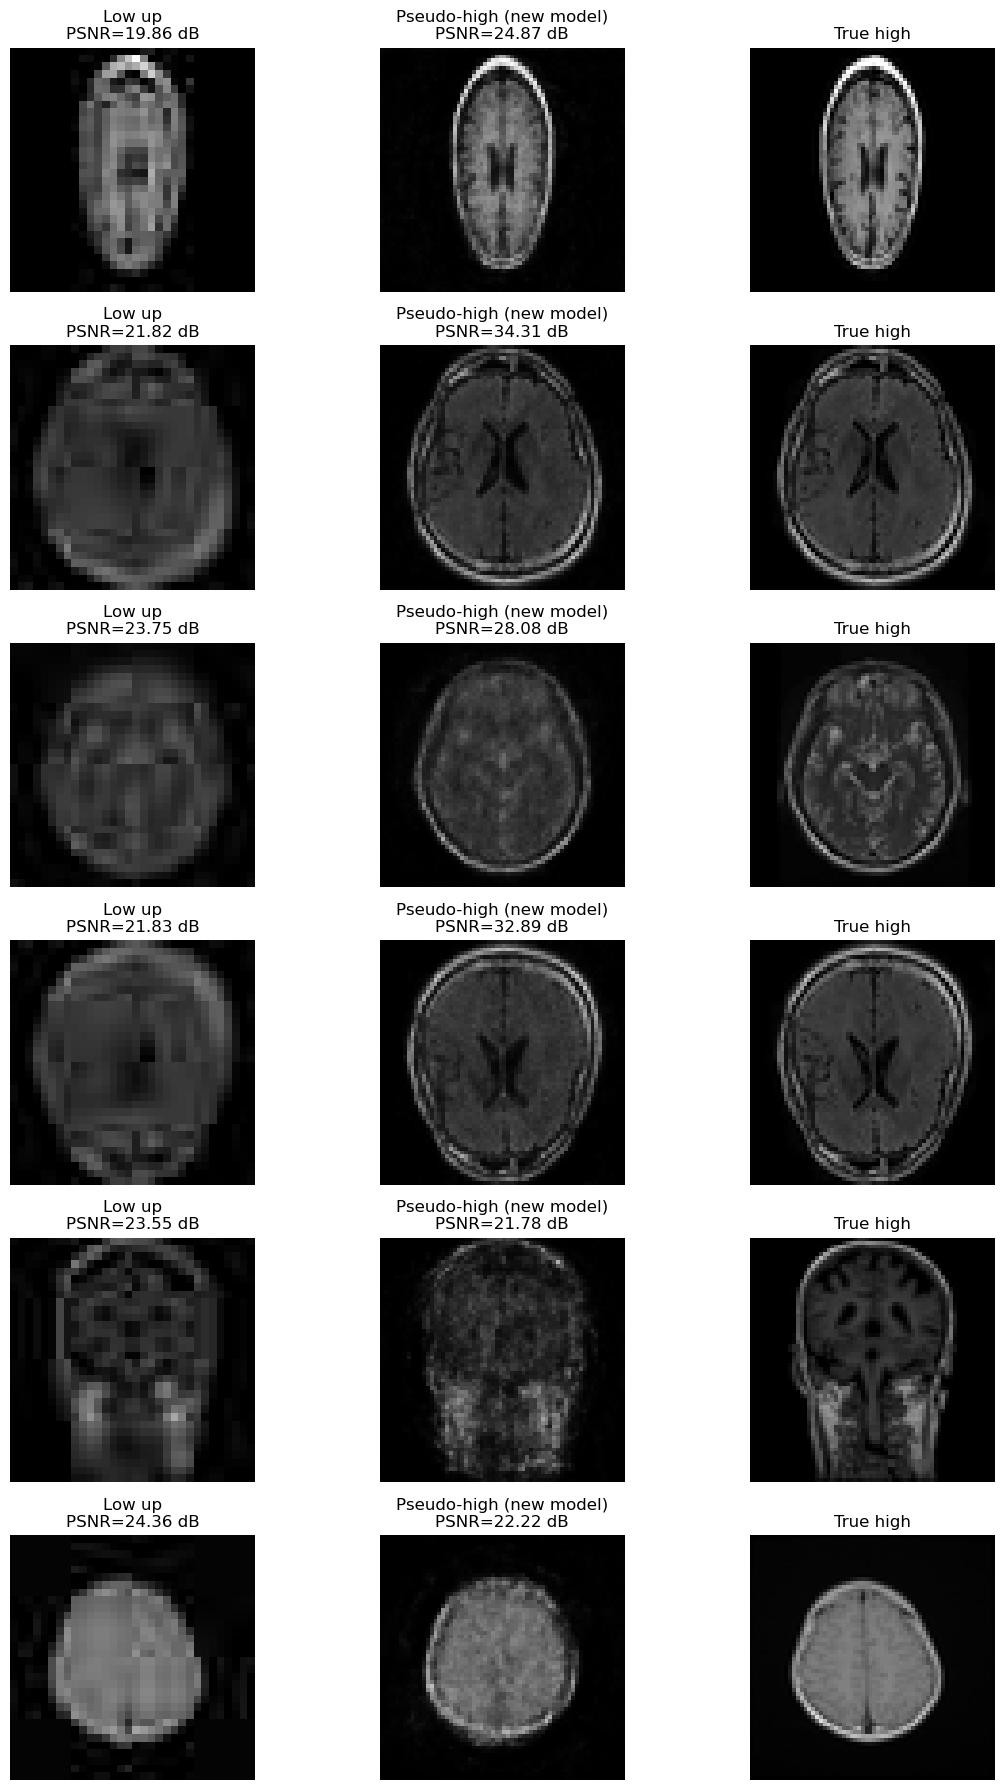

In [12]:
# --------------------
# Visualisations qualitatives sur le test set
# --------------------
N_SHOW = 6
show_indices = np.random.default_rng(SEED).choice(len(test_idx), size=min(N_SHOW, len(test_idx)), replace=False)

model.eval()
fig, axes = plt.subplots(len(show_indices), 3, figsize=(12, 3 * len(show_indices)))
if len(show_indices) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, local_idx in enumerate(show_indices):
    global_idx = test_idx[int(local_idx)]
    low_np, high_np = full_dataset[global_idx]

    low = low_np.unsqueeze(0).to(DEVICE)
    high = high_np.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pseudo = model.sample_from_low(low)

    low_up = F.interpolate(low, size=(HIGH_SIZE, HIGH_SIZE), mode='nearest').squeeze(0).cpu()
    pseudo_img = pseudo.squeeze(0).cpu()
    high_img = high.squeeze(0).cpu()

    p_low = psnr_torch(low_up, high_img)
    p_ps = psnr_torch(pseudo_img, high_img)

    axes[row, 0].imshow(low_up.squeeze(0).numpy(), cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title(f'Low up\nPSNR={p_low:.2f} dB')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(pseudo_img.squeeze(0).numpy(), cmap='gray', vmin=0, vmax=1)
    axes[row, 1].set_title(f'Pseudo-high (new model)\nPSNR={p_ps:.2f} dB')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(high_img.squeeze(0).numpy(), cmap='gray', vmin=0, vmax=1)
    axes[row, 2].set_title('True high')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()